In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/credit-risk-customers/credit_customers.csv


# Face 1: Cleaning the data, Dropping null values, duplicates, and changing values if neccessary

In [2]:
# Basic
url = '/kaggle/input/credit-risk-customers/credit_customers.csv'
sns.set_theme()
pd.options.mode.chained_assignment = None  # default='warn'
pd.set_option('display.max_columns', None) #It allows us to display all the column


In [3]:
# Importing the dataset
opensource = pd.read_csv(url,delimiter=',')
df = opensource.copy()
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,4.0,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,2.0,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,3.0,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,4.0,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,4.0,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [4]:
df.dtypes # All the values seems to be in the correct format
df.isnull().sum() # Checking for null values --> We do not have any null values in the dataset
df = df.drop_duplicates() # Dropping duplicates


# Checking all the unique values from each column 
#for i in np.unique(df.columns):
    #print(df[i].unique(),'\n')
    
    
# Cleaning the values from the job column for better understanding
df['job'] = df['job'].str.replace('unskilled resident','unskilled')
df['job'] = df['job'].str.replace('high qualif/self emp/mgmt','highqualif/selfemp')
df['job'] = df['job'].str.replace('unemp/unskilled non res','unemp/unsk/ nonres')

# Face 2: Data visualization 

## Question / Task 1: Get the measures of centra tendencies regarding loan duration

          duration
count  1000.000000
mean     20.903000
std      12.058814
min       4.000000
25%      12.000000
50%      18.000000
75%      24.000000
max      72.000000


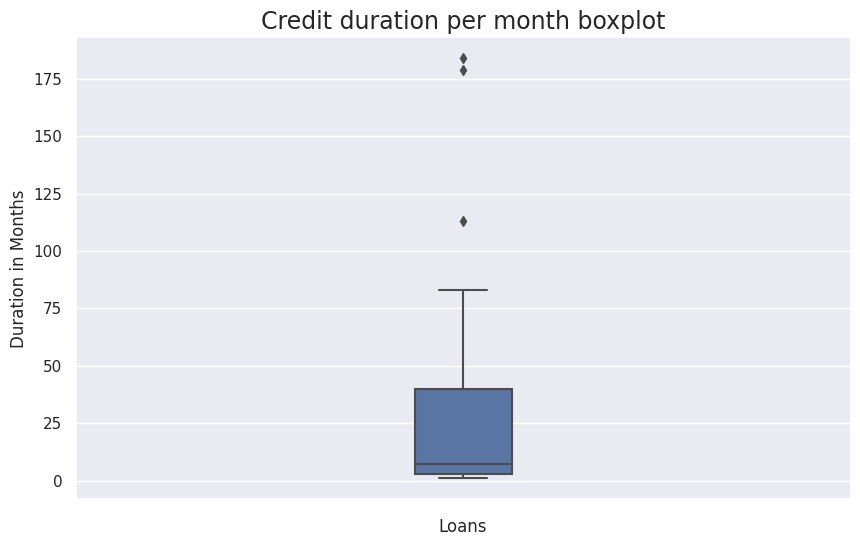

In [5]:
print(df[['duration']].describe())
df1 = df.groupby('duration')[['duration']].count()

plt.figure(figsize=(10,6))
sns.boxplot(data=df1,y=df1.values,width=0.125)
plt.ylabel('Duration in Months')
plt.xlabel('Loans')
plt.title('Credit duration per month boxplot', fontdict={'fontsize':'17'})
plt.show()

-----

## Task / Question 2: Check the loan frequencies per purpose and see which purpose is the highest one

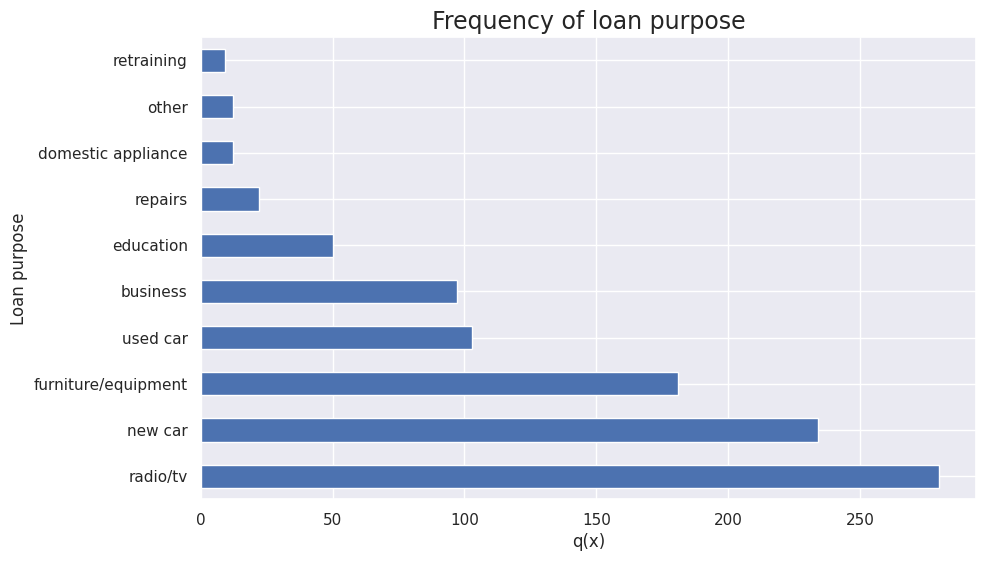


 We can notice that there is a highest approach to take loans for buying Ratios / Tvs than anyother good / service available


In [6]:
df2 = df.groupby('purpose')[['credit_amount']].count().sort_values(by='credit_amount',ascending=False)



df2.plot(kind='barh',legend=False,figsize=(10,6))
plt.title('Frequency of loan purpose',fontdict={'fontsize':'17'})
plt.ylabel('Loan purpose')
plt.xlabel('q(x)')
plt.show()

print('\n We can notice that there is a highest approach to take loans for buying Ratios / Tvs than anyother good / service available')

----

## Task / Question 3: Check the measures of central tendencies regarding Credit Amount by Purpose 

In [7]:
df3 = df.groupby('purpose')['credit_amount'].describe().T
df3

purpose,business,domestic appliance,education,furniture/equipment,new car,other,radio/tv,repairs,retraining,used car
count,97.000000,12.000000,50.000,181.000000,234.000000,12.000000,280.000000,22.000000,9.000000,103.000000
mean,4158.041237,1498.000000,3180.400,3066.988950,3063.025641,8209.333333,2487.653571,2728.090909,1205.888889,5370.223301
std,3231.484456,1012.510741,3017.942,2034.146228,2962.645077,6112.703156,2073.693150,2627.490364,891.481274,2890.972185
min,609.000000,343.000000,392.000,428.000000,250.000000,1164.000000,338.000000,454.000000,339.000000,1236.000000
25%,1908.000000,1131.250000,1198.250,1747.000000,1241.500000,2410.500000,1261.000000,1214.500000,894.000000,2917.000000
50%,3161.000000,1249.000000,1884.500,2578.000000,1980.000000,6948.000000,1890.000000,1749.000000,932.000000,4788.000000
75%,5293.000000,1359.500000,4425.250,3643.000000,3632.500000,12649.000000,3038.000000,3203.250000,1238.000000,7498.000000
max,15945.000000,3990.000000,12612.000,14179.000000,14896.000000,18424.000000,15653.000000,11998.000000,3447.000000,12976.000000


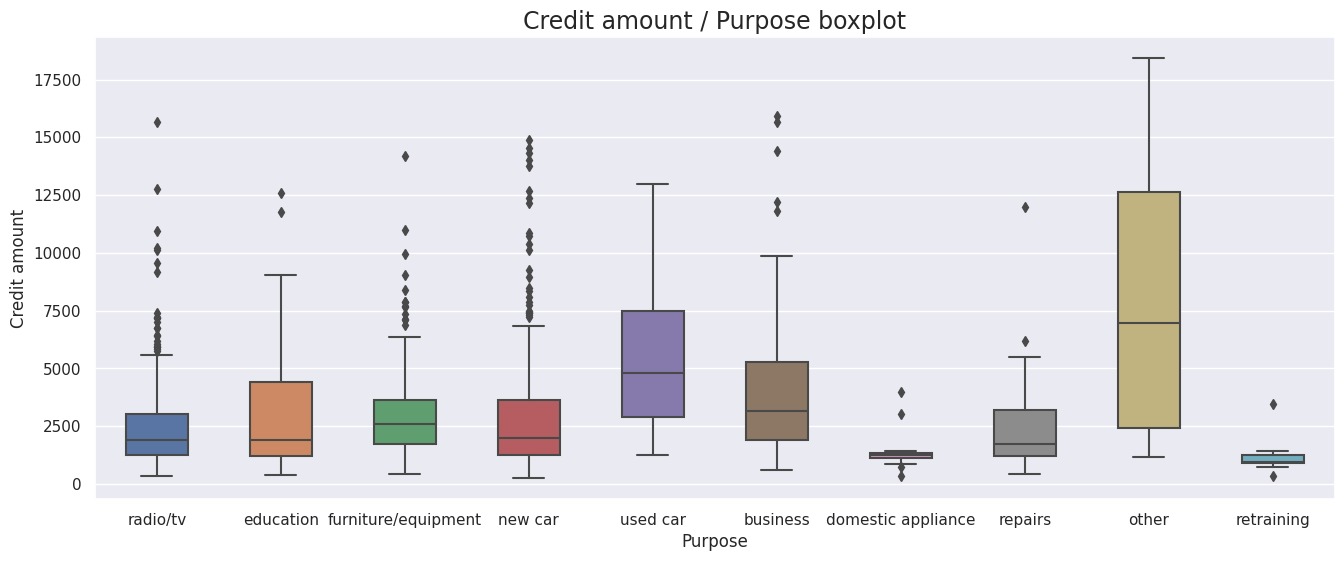

In [8]:
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.5, orient='v', x='purpose')
plt.title('Credit amount / Purpose boxplot', fontdict={'fontsize':'17'})
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

---

## Task / Question 4: Check the relationship between the Credit amount and Employment Status. Get the measures of central tendencies and create a boxplot for a better view

The mean credit amount take it for people with employment status 1<=X<4 was : 3125.29
The mean credit amount take it for people with employment status 4<=X<7 was : 3601.7
The mean credit amount take it for people with employment status <1 was : 2952.45
The mean credit amount take it for people with employment status >=7 was : 3224.62
The mean credit amount take it for people with employment status unemployed was : 4216.76




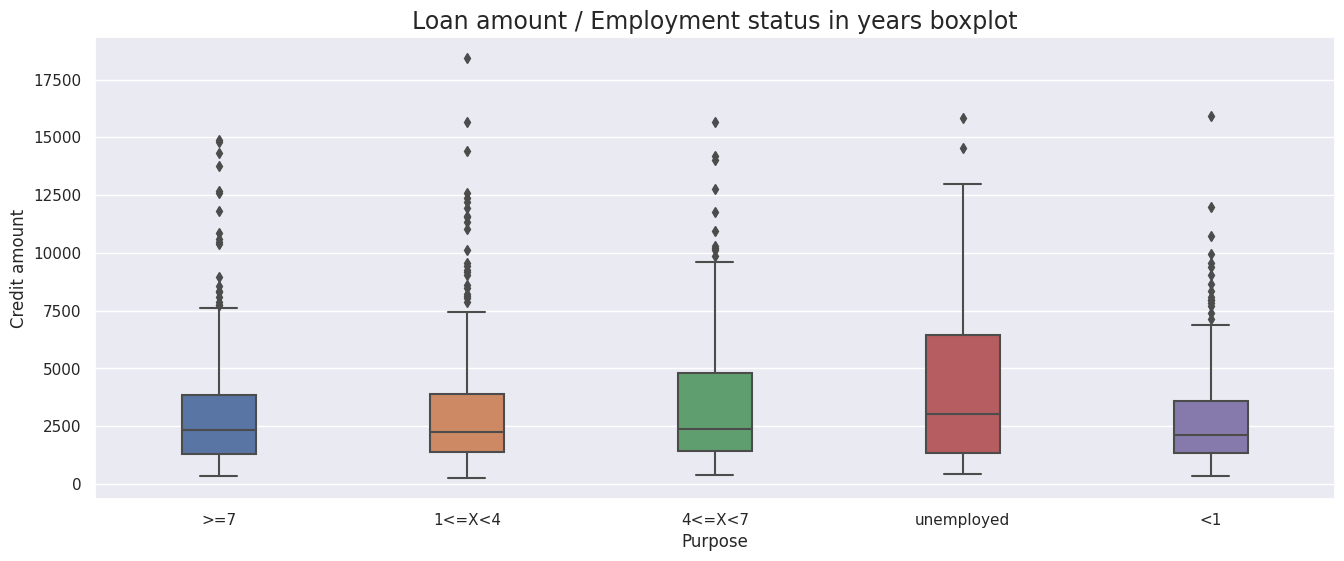

In [9]:
df4 = df.groupby('employment')['credit_amount'].describe().round(2).T
df4 = df4.astype(str)
df4

for i in range(5):
    print('The mean credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[1,i])
print('\n')

plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.3, orient='v', x='employment')
plt.title('Loan amount / Employment status in years boxplot', fontdict={'fontsize':'17'})
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

## Question / Task 4.2: Check the purpose of each group of employment status and see what were they getting a loan for and see if there is a relation between them

Axes(0.125,0.11;0.775x0.77) 



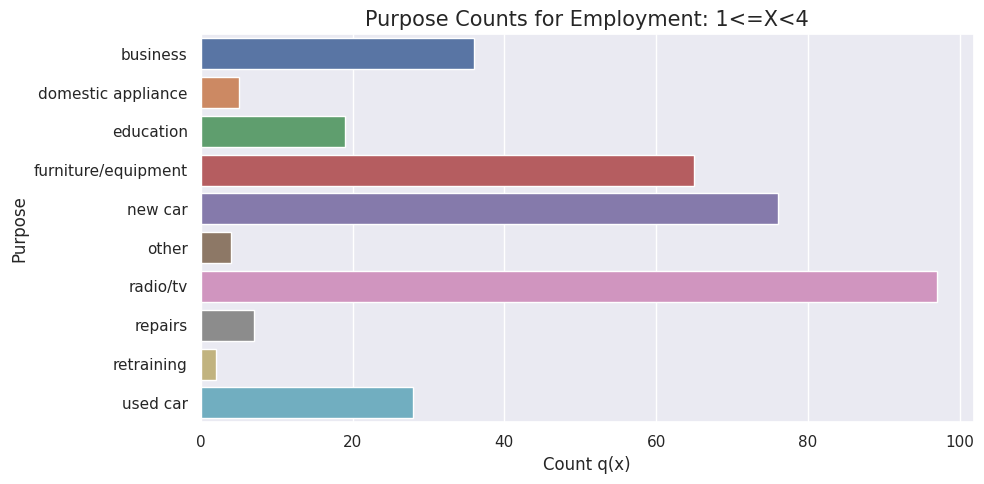

Axes(0.125,0.11;0.775x0.77) 



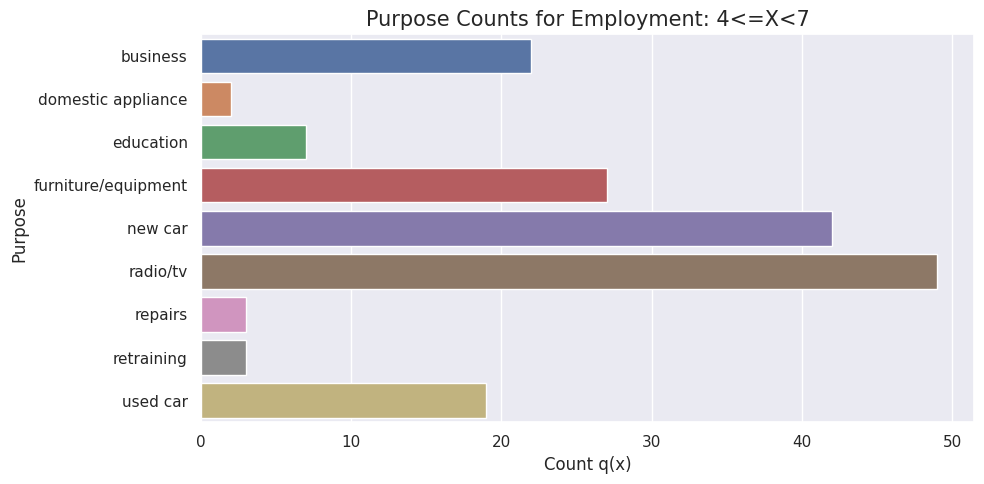

Axes(0.125,0.11;0.775x0.77) 



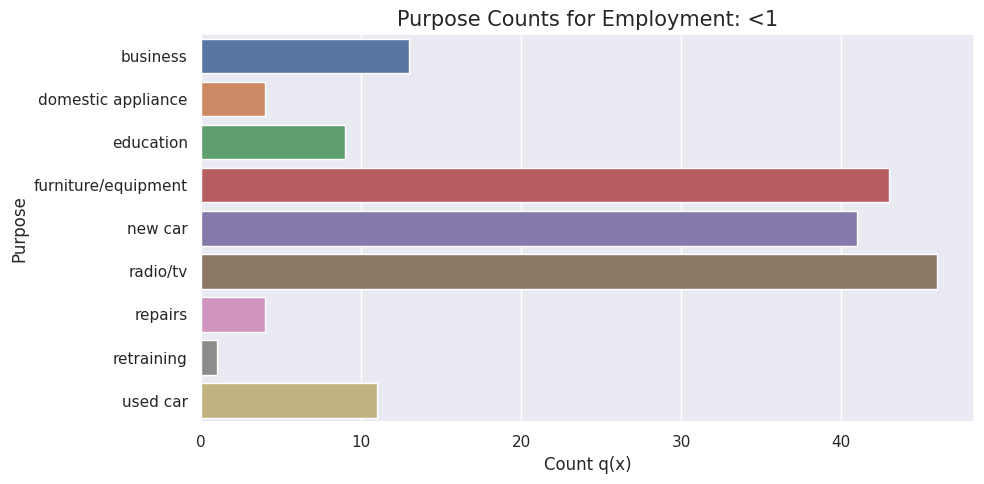

Axes(0.125,0.11;0.775x0.77) 



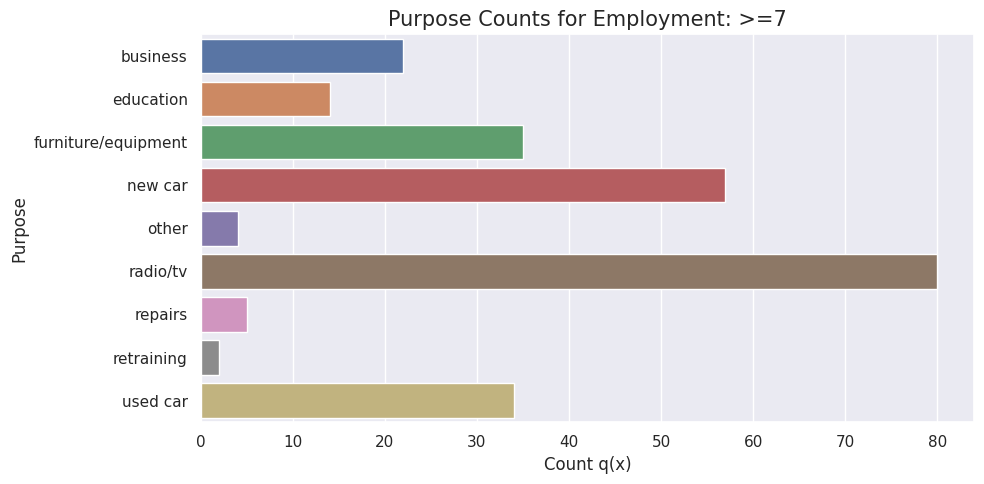

Axes(0.125,0.11;0.775x0.77) 



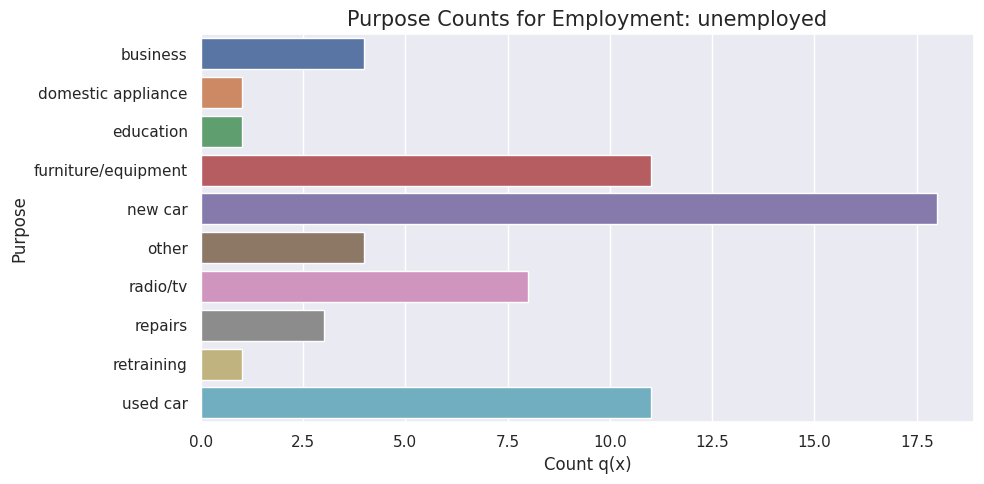

In [10]:
df4 = df[['employment','purpose']].value_counts().sort_index()
df4 = df4.reset_index()
df4.head()

employment_categories = df4['employment'].unique()

for category in employment_categories:
    plt.figure(figsize=(10, 5))  
    
    subset = df4[df4['employment'] == category]
    
    print(sns.barplot(data=subset, y='purpose', x='count',orient='h'),'\n')
    plt.title(f'Purpose Counts for Employment: {category}', fontdict={'fontsize':'15'})
    plt.ylabel('Purpose')
    plt.xlabel('Count q(x)')
    plt.tight_layout() 
    plt.show()

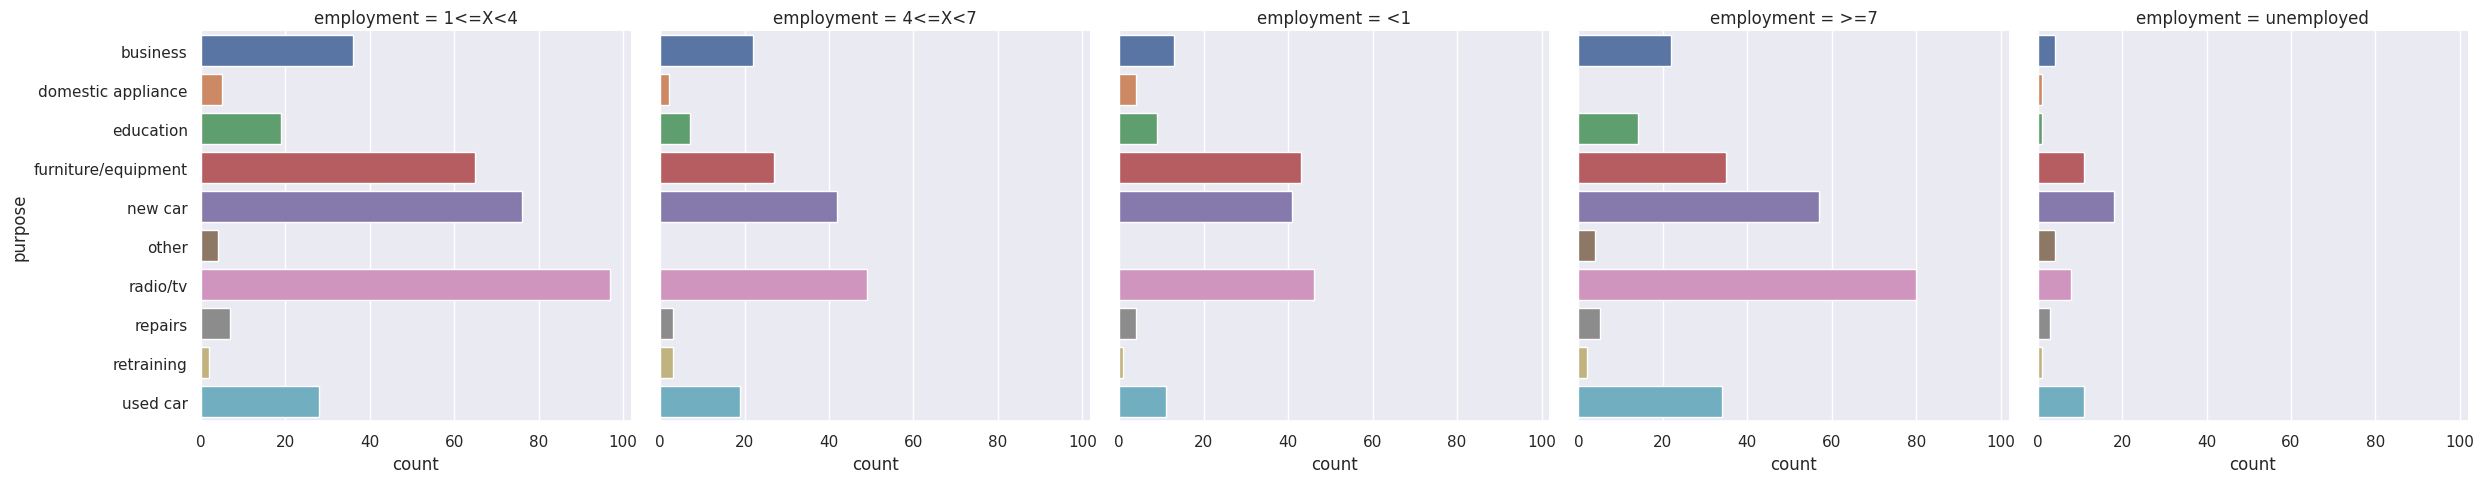

In [11]:

df4 = df[['employment','purpose']].value_counts().sort_index()
df4 = df4.reset_index()
df4.head()
sns.catplot(data=df4, x='count',y='purpose',col='employment',kind='bar',orient='h')
plt.show()

---

## Task / Question 5: Check which group is the one that took the highest amount of loans

employment
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: employment, dtype: int64 

The employment status group which request most loans was 1<=X<4 with a total of 339 loans


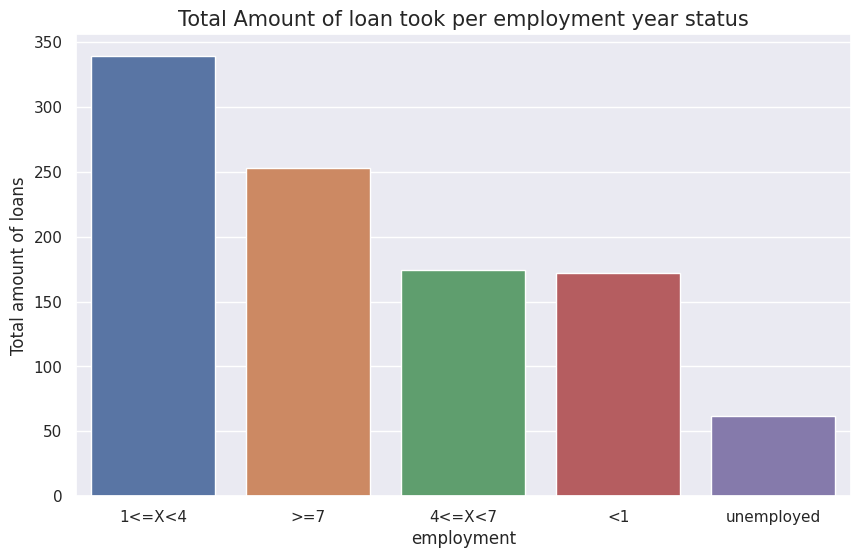

In [12]:
df5 = df.groupby('employment')['employment'].count().sort_values(ascending=False)
print(df5,'\n')
df5_str = df5.astype(str)
print('The employment status group which request most loans was '+df5_str.index[0]+' with a total of '+ df5_str.iloc[0]+ ' loans')

plt.figure(figsize=(10,6))
plt.title('Total Amount of loan took per employment year status', fontdict={'fontsize':'15'})
plt.xlabel('Employment')
plt.ylabel('Total amount of loans')
sns.barplot(x=df5.index,y=df5.values)
plt.show()

----

## Task / Question 6: Check the relation betwen the type of job and loan duration

job
skilled               630
unskilled             200
highqualif/selfemp    148
unemp/unsk/ nonres     22
Name: duration, dtype: int64 



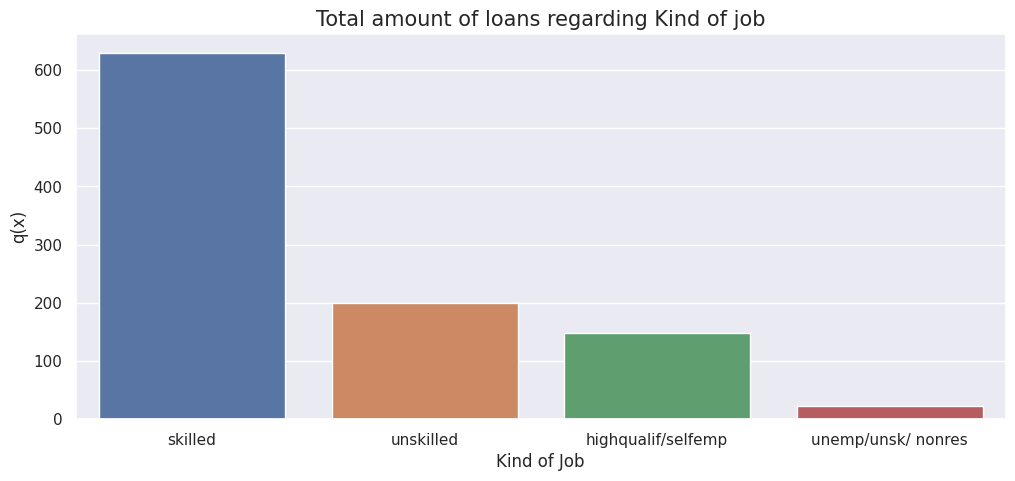

In [13]:
df6 = df.groupby('job')['duration'].count().sort_values(ascending=False)
print(df6,'\n')

plt.figure(figsize=(12,5))
sns.barplot(x=df6.index,y=df6.values)
plt.title('Total amount of loans regarding Kind of job', fontdict={'fontsize':'15'})
plt.xlabel('Kind of Job')
plt.ylabel('q(x)')
plt.show()

Axes(0.125,0.11;0.775x0.77)


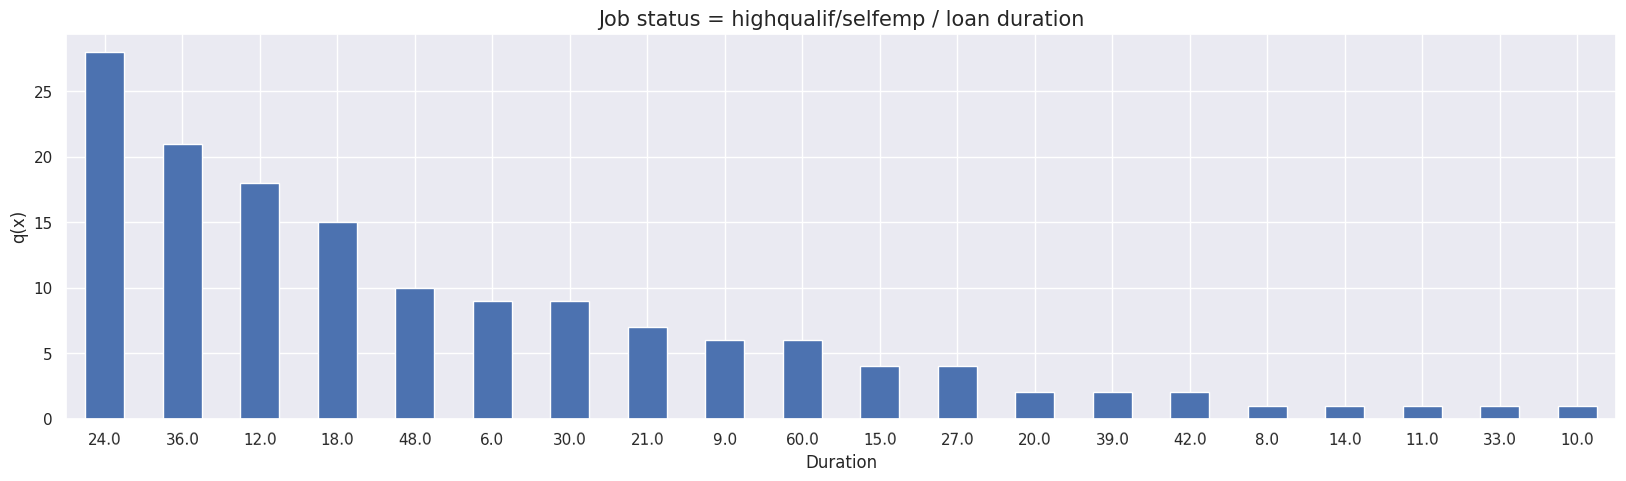

Axes(0.125,0.11;0.775x0.77)


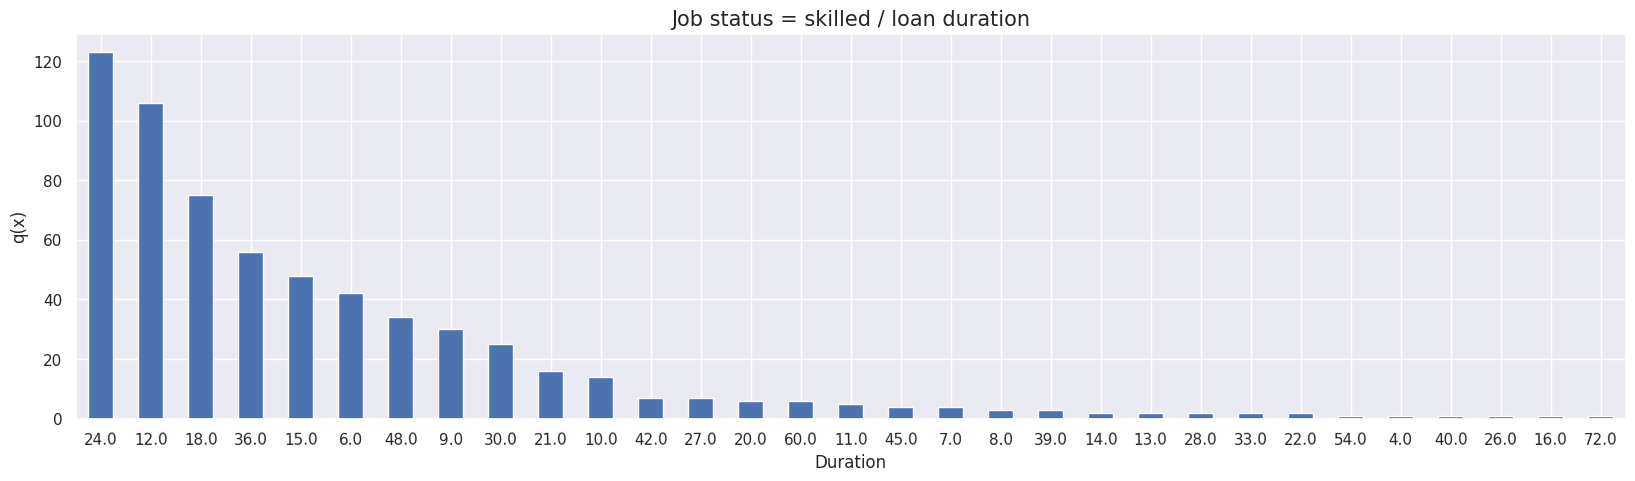

Axes(0.125,0.11;0.775x0.77)


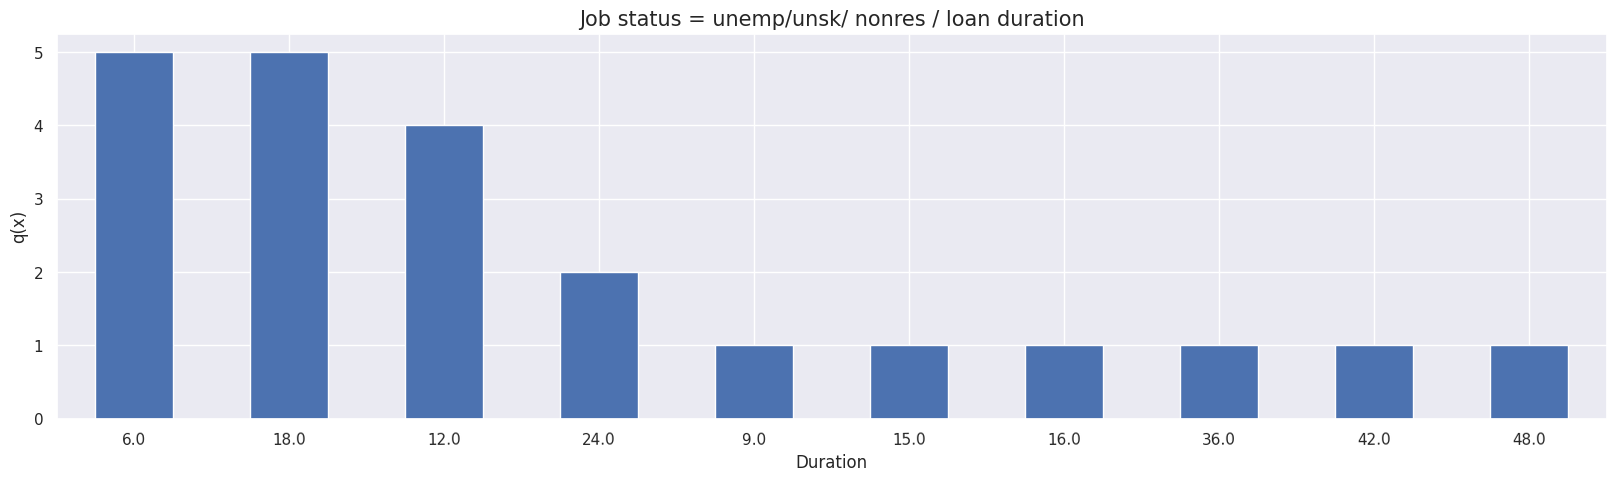

Axes(0.125,0.11;0.775x0.77)


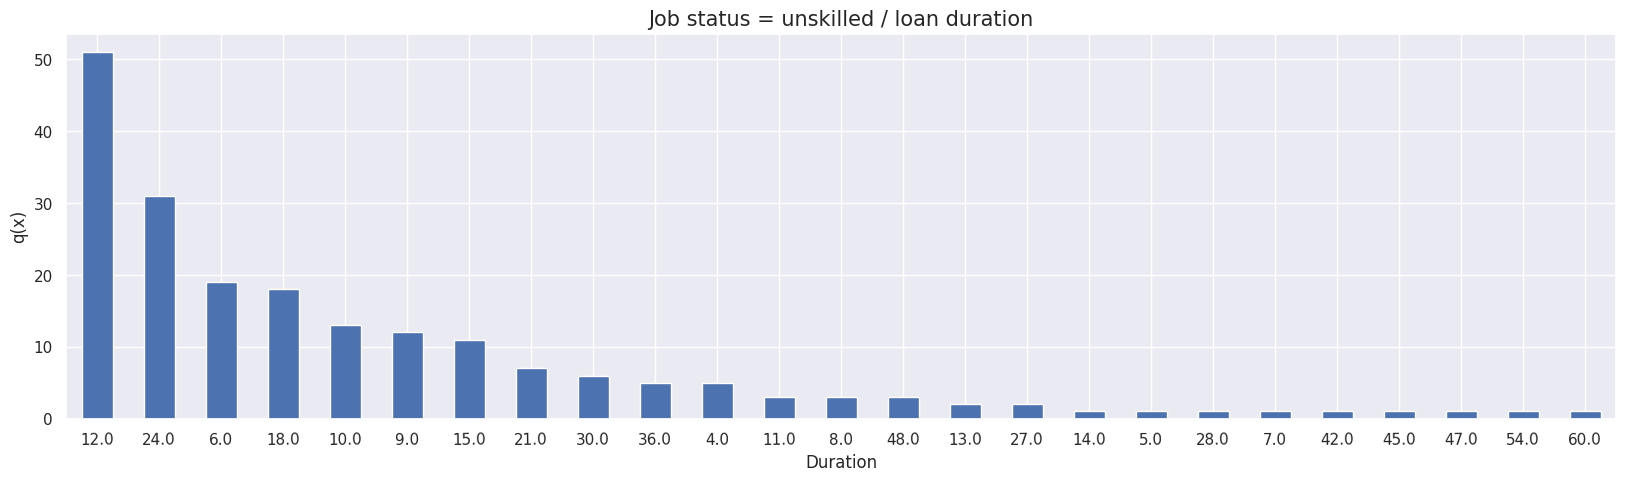

In [14]:
df_skilled = df
for i in np.unique(df['job']):
    df_skilled = df_skilled[['duration','job']]
    sub = df_skilled[df_skilled['job'] == i].value_counts()
    sub = sub.reset_index()
    print(sub.plot(kind='bar',x='duration',figsize=(20,5),rot=1,legend=None))
    
    plt.title(f'Job status = {i} / loan duration',fontdict={'fontsize':'15'})
    plt.xlabel('Duration')
    plt.ylabel('q(x)')
    plt.show()

---

## Question / Task 7: Check which group of worker took most loans and their variables
* For this Task we will use the **foreigner worker, and number of dependents**

                               q(x)
foreign_worker num_dependents      
no             1.0               26
               2.0               11
yes            1.0              819
               2.0              144 


From all the loans taken, 37 are from original residents and 963 are from foreign workers

Here a better view regarding number of dependents:


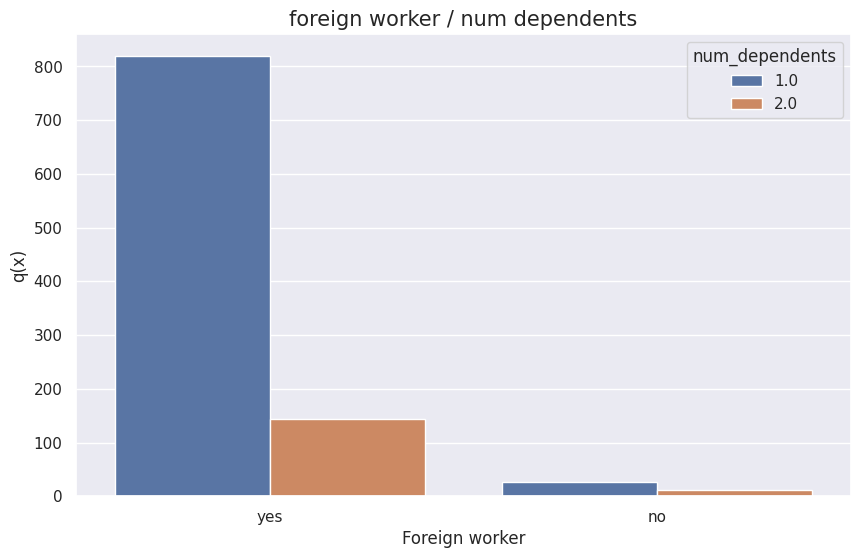

In [15]:
df7_yes_no = df.groupby('foreign_worker')['foreign_worker'].count()
df7_yes_no =df7_yes_no.astype(str)

df7 = df.groupby(['foreign_worker','num_dependents'])[['foreign_worker']].count()
df7 = df7.rename(columns={'foreign_worker':'q(x)'})
print(df7,'\n\n')

print('From all the loans taken, '+ df7_yes_no.iloc[0]+' are from original residents and '+df7_yes_no.iloc[1]+' are from foreign workers')
print('\nHere a better view regarding number of dependents:')


plt.figure(figsize=(10,6))
sns.countplot(data=df,x='foreign_worker', orient='h', hue = 'num_dependents')
plt.title('foreign worker / num dependents', fontdict={'fontsize':'15'})
plt.ylabel('q(x)')
plt.xlabel('Foreign worker')
plt.show()

## Question / Task 8: Check what group of customer regarding personal status took most loans 

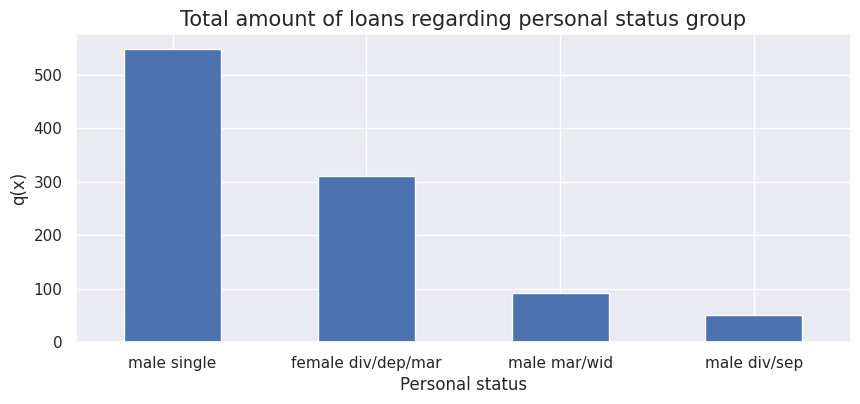

The group that took most loans is: male single with an amount of 548 loans


In [16]:
df_personal_status = df['personal_status'].value_counts().sort_values(ascending=False)
df_personal_status.plot(kind='bar', rot=0,figsize=(10,4))
plt.title('Total amount of loans regarding personal status group', fontdict={'fontsize':'15'})
plt.xlabel('Personal status')
plt.ylabel('q(x)')
plt.show()


print('The group that took most loans is: '+df_personal_status.index[0]+' with an amount of '+ str(df_personal_status.iloc[0])+' loans')

---

# Conclusions: 

### Task 1: From the first task we can say that the 50% of the loans have a duration of <=18 months or >= 18 months, and the mean duration is 20 months
### Task 2: The main purpose to take a loan is for the purchase of a Radio or TV and the least purpose is retraining
### Task 3: The mean loan took for each purspose was:

In [17]:
df3.loc[['mean']].round()

purpose,business,domestic appliance,education,furniture/equipment,new car,other,radio/tv,repairs,retraining,used car
mean,4158.0,1498.0,3180.0,3067.0,3063.0,8209.0,2488.0,2728.0,1206.0,5370.0


### Task 4: The main purpose for people between 1 and 4 years of experience working was for the purchase of a Radio / Tv. For a better view of the rest of the group please go above to the task section 4
### Task 5: The group which most took loans was the one between 1 and 4 years of experience 
### Task 6: The job status group who took most loans were the skilled ones
### Task 6.2: Most of the loans for the job status "skilled" was taken in 24 months. To get a better view of this please go above to the task section 7
### Task 7: We can confirm that most of loans were taken by foreign workers and that most of them have 1 dependent at least
### Task 8: Single male are most likely to take loans since these group represent more than 500 cases